In [1]:
!pip install xgboost

In [10]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metircs
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [3]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


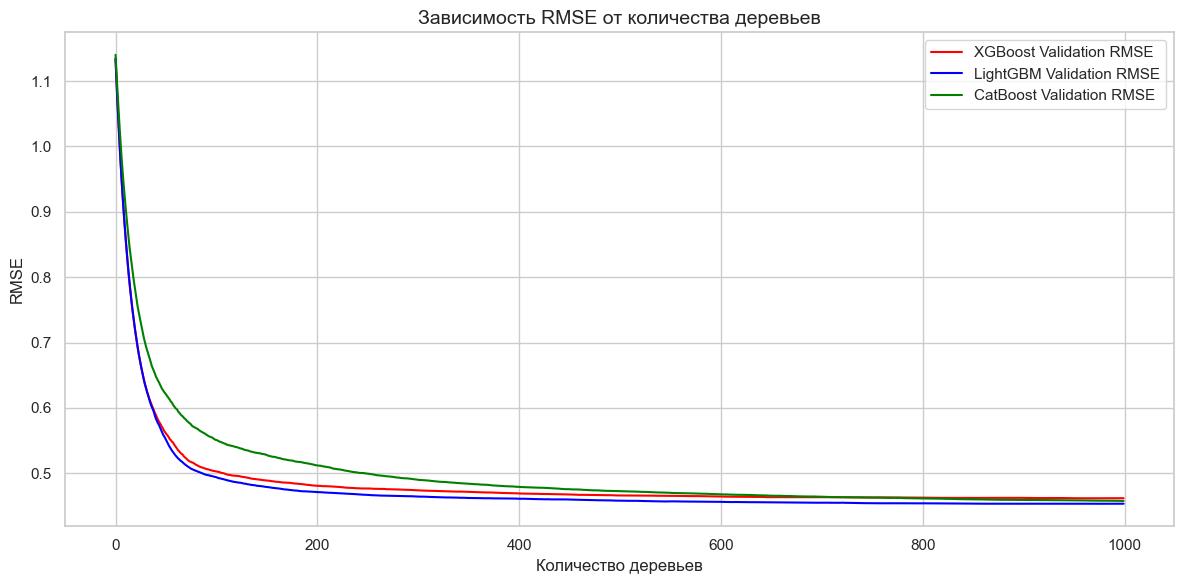

In [4]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', random_seed=42)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
SELECTED_N_ESTIMATORS = 400

In [6]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[5, 7],
    'subsample': [0.8, 1.0]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.8, 1.0]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [5, 7],
    'subsample':[0.8, 1.0]
}

def simple_grid_search(model_name, param_grid):
    print(f"--- Запуск Grid Search для {model_name} ---")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1)
        else:
            model = cb.CatBoostRegressor(**params, iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)

--- Запуск Grid Search для XGBoost ---
Лучший Validation RMSE: 0.4621
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}

--- Запуск Grid Search для LightGBM ---
Лучший Validation RMSE: 0.4557
Лучшие параметры: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8}

--- Запуск Grid Search для CatBoost ---
Лучший Validation RMSE: 0.4564
Лучшие параметры: {'depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}



In [7]:
results = []

for name in['XGBoost', 'LightGBM', 'CatBoost']:
    params = best_params_dict.get(name)

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1, **params)
    else:
        model = cb.CatBoostRegressor(iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0, **params)

    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time() - start_time

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

,Модель,Время обучения,MAE,RMSE,R2 Score
0,XGBoost,0.733,0.2912,0.4476,0.8471
1,LightGBM,0.760,0.2862,0.4379,0.8537
2,CatBoost,0.506,0.2967,0.4493,0.8460


In [8]:
class My_boost :
    def __init__(self, n , lr, depth, seed ) -> None:
        self.n = n
        self.lr = lr
        self.depth = depth
        self.seed = seed
        self.trees = []
    def fit(self, X, y) :
        self.initial_leaf = y.mean()
        predictions = np.zeros(len(y)) + self.initial_leaf

        for i in range (self.n):
            antigrad = y - predictions
            tree = DecisionTreeRegressor(max_depth = self.depth, random_state= self.seed, criterion= "friedman_mse")

            tree.fit(X, antigrad)
            predictions += self.lr * tree.predict(X)
            self.trees.append(tree)
    def predict(self,X) :
        predictions = np.zeros(len(X)) + self.initial_leaf
        for i in range(self.n):
            predictions += self.lr * self.trees[i].predict(X)

        return predictions


In [24]:
try_boost = My_boost(n =100, lr= 0.1, depth = 8, seed = 42)
try_boost.fit(X_train,y_train)
y_my_pred = try_boost.predict(X_val)
print(r2_score(y_val,y_my_pred))
print()
###оно работает и даже предсказывает

0.8327657868160693


Теперь будем реализовывать GBClassifier

In [12]:
##загрузим подходящий датасет
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X1 = pd.DataFrame(data.data, columns=data.feature_names)
y1 = pd.Series(data.target, name="target")

In [18]:
def calculate_res(y,proba) :
    residuals = y - proba
    return residuals

def sigmoid(logit) :
    prob = np.exp(logit)/1+np.exp(logit)
    return prob

In [37]:
class My_GBclassifier :
    def __init__ (self, n , lr, depth,seed, threshold) -> None :
        self.n= n
        self.lr = lr
        self.depth = depth
        self.seed = seed
        self.trees = []
        self.threshold = threshold
    def fit(self,X,y) :
        self.classes, self.n_classes = np.unique(y, return_counts= True)
        logit_in = self.n_classes[1]/self.n_classes[0]
        self.initial_leaf =  np.log(logit_in) 
        predictions = np.full(len(y), fill_value= np.log(logit_in))
        
        for i in range(self.n) :
            probs = sigmoid(predictions)
            residuals = calculate_res(y,probs)
            
            tree =  DecisionTreeRegressor(max_depth = self.depth, random_state= self.seed, criterion= "friedman_mse")
            tree.fit(X,residuals)
            self.trees.append(tree)
            predictions += self.lr* tree.predict(X)
    def predict_proba(self,X) :
            F = np.full(X.shape[0],self.initial_leaf)
            for tree in self.trees :
                F += self.lr * tree.predict(X)
                F_pr = sigmoid(F)
            return F_pr
    def predict(self, X):
            return (self.predict_proba(X) >= self.threshold).astype(int)

In [39]:
mgb = My_GBclassifier(100, 0.1, 3, 42, threshold = 0.5)

In [40]:
X1_train,X1_test,y1_train,y1_test = train_test_split(X1,y1,test_size= 0.2,random_state = 42)
mgb.fit(X1_train,y1_train)

In [41]:
np.log(200/150)

np.float64(0.28768207245178085)

In [45]:
prd = mgb.predict(X1_test)

In [46]:
r2_score(y1_test, prd)

0.8132983950212905

In [48]:
from sklearn.ensemble import GradientBoostingClassifier
gboost = GradientBoostingClassifier(n_estimators=100, learning_rate= 0.1,max_depth= 3, random_state= 42)
gboost.fit(X1_train,y1_train)
prdct_t = gboost.predict(X1_test)
r2_score(y1_test,prdct_t)

0.8132983950212905